# **Agent 시스템 확장_Tools**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [2]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 12.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires request

#### 2) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 확인

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/LangGraph/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-6HnpTor5FDdHd3WXGaRUshfzSdb


## 2.간단한 Chatbot Agent 만들기

In [6]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, AnyMessage

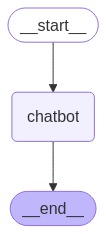

### (1) State 정의

LangGraph에서 LLM 메시지 히스토리를 자동으로 관리하기 위해 사용되는 특별한 필드 정의 방식

In [7]:
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 리스트에 메시지를 append

### (2) Node 정의

In [8]:
llm = ChatOpenAI(model="gpt-4.1-mini")  # 언어 모델을 gpt-4o로 설정

def chatbot(state: State):
    result = llm.invoke(state["messages"])
    return {"messages": result}   # 응답 "messages"에 넣어 반환

### (3) 그래프 정의

In [9]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.set_entry_point("chatbot")      # "chatbot"는 START로 연결
builder.set_finish_point("chatbot")     # "chatbot"는 END로 연결

# builder.add_edge(START, "chatbot")
# builder.add_edge("chatbot", END)

# compile the graph
graph = builder.compile()

* 그래프 시각화

In [10]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) Graph 실행

* 실행1

In [11]:
result = graph.invoke({"messages": [HumanMessage("안녕")]})

In [12]:
result

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='71a0cefa-68e2-4f81-87d3-7cc5ee41a198'),
  AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-CPjjtYuBc1lYAmW0TLt1f7ObOW8zQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--81ff76cf-7586-487c-a17e-f0c7ee4a8390-0', usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [13]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

안녕
================================== Ai Message ==================================

안녕하세요! 어떻게 도와드릴까요?


> 메시지 객체(HumanMessage, AIMessage 등)는 LangChain에서 제공하는 특수 클래스.  
.pretty_print()는 그 메시지를 깔끔하고 보기 좋게 출력하는 함수

* [참조]실행2
    * input을 받아서
    * .stream(...)
        * LangGraph에서 .invoke()는 전체 실행 결과를 한 번에 반환
        * 반면 .stream()은 실행되는 중간 중간 결과를 이벤트처럼 출력할 수 있어! 상태를 점진적으로 업데이트하며 리얼타임 반응처럼 처리 가능
        * 여기서는 state = {"messages": ("user", user_input)}가 전달됨
        * 즉, 사용자 메시지를 상태로 넘김
    * value["messages"][-1].content
        * 각 event는 그래프 실행 도중 생성된 중간 상태들
        * 그 중 "messages" 키의 가장 마지막 메시지(content)를 출력
        * 즉, 에이전트의 최신 응답만 뽑아서 보여줌

In [21]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("잘가!")
        break
    for event in graph.stream({"messages": [HumanMessage(user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"].content)

User: 안녕?
Assistant: 안녕하세요! 어떻게 도와드릴까요?
User: 내 이름은 핑크퐁
Assistant: 안녕하세요, 핑크퐁님! 만나서 반가워요. 어떻게 도와드릴까요?
User: quit
잘가!


## 3.Tool 사용하기

In [ ]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

### (1) Custom Tool 만들기

#### 1) Tool 준비하기

* langchain_core.tools의 tool을 import하면 @tool 데코레이터만으로 함수를 langchain의 tool로 변환 가능

In [ ]:
@tool
def calculator_tool(expression: str) -> str:  # type hint : 함수의 출력 type은 str
    '''수식을 입력 받아 계산하는 도구'''
    try:
        result = eval(expression)  # Python 내장 함수 eval()을 사용해서 문자열로 된 식을 계산
        return f"계산 결과: {result}"
    except Exception as e:
        return f"오류 발생: {str(e)}"

@tool
def get_weather(location: str):
    """현재 날씨 정보를 반환합니다."""
    # 입력된 지역이 "서울"인 경우에 해당하는 날씨 정보를 반환합니다.
    if location in ["서울"]:
        return "현재 온도는 20도이며 맑고 화창한 날씨입니다."
    else:
        # "서울"이 아닌 경우, 다른 날씨 정보를 반환합니다.
        return "현재 온도는 10도이며 조금 쌀쌀합니다."


#### 2) Tool 등록 및 ToolNode 생성

- tools 리스트: 정의된 tool 함수들을 리스트에 담습니다.
- ToolNode 인스턴스: 등록된 tools들을 관리하고 호출 요청을 처리하기 위해 ToolNode를 생성합니다.

In [ ]:
#Tool Node로 묶어줄 때, 리스트 형태로 tool들을 함께 제공합니다.
tools = [get_weather, calculator_tool]
tool_node = ToolNode(tools)

In [ ]:
#bind_tools() 함수로 LLM에게 어떤 tool들이 있는지 인지시켜 도구를 활용하도록 만듭니다.
from langchain_openai import ChatOpenAI

llm_with_tools = ChatOpenAI(model="gpt-4.1-mini", temperature=0
                              ).bind_tools(tools)

* tool 사용해보기

In [ ]:
llm_with_tools.invoke("서울 날씨는 어때?").tool_calls

[{'name': 'get_weather',
  'args': {'location': '서울'},
  'id': 'call_9WfY5mLjW00m0ct8kIl9URoe',
  'type': 'tool_call'}]

| 필드 | 의미 |
| ---- | ---- |
| name | 사용하려는 툴의 이름 → get_weather |
| args | 툴에 넘겨줄 인자(argument) → {"location": "서울"} |
| id | 호출 ID (LangGraph나 LangChain 내부 추적용) |
| type | "tool_call" → 이 응답은 도구 호출이라는 의미 |

In [ ]:
llm_with_tools.invoke("오늘 점심은 뭐 먹을까?").tool_calls

[]

In [ ]:
llm_with_tools.invoke("1+3*(20-15)").tool_calls

[{'name': 'calculator_tool',
  'args': {'expression': '1+3*(20-15)'},
  'id': 'call_hFf8yoRtAb5ufSxnNvGgMOZp',
  'type': 'tool_call'}]

In [ ]:
tool_node.invoke({"messages": [llm_with_tools.invoke("서울 날씨는 어때?")]})

{'messages': [ToolMessage(content='현재 온도는 20도이며 맑고 화창한 날씨입니다.', name='get_weather', tool_call_id='call_bR3N1MYRBjURT1V29XIfY2Wf')]}

#### 3) 그래프 만들기

* 그래프 흐름
    - 내장 툴들을 불러오기 (load_tools())
    - 하나의 ToolNode에 묶기
    - LangGraph로 LLM → ToolNode → LLM 구조 실행하기


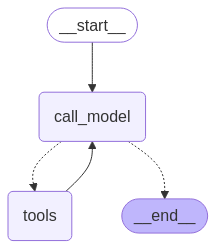

In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# 조건 분기 함수: 툴 호출이 필요한가?
def should_continue(state: State) -> Literal["tools", END]:  # 출력은 반드시 "tools" 혹은 END 여야 함.
    messages = state["messages"]
    last_message = messages[-1]  # 가장 최근 message
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue,
                            #   {"tools": "tools", END: END}
                              )
builder.add_edge("tools", "call_model")  # 루프 연결

# 컴파일
graph = builder.compile()

* 그래프 시각화

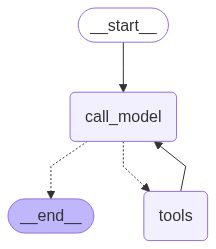

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
final_state = graph.invoke(
    {"messages": [HumanMessage(content="서울의 날씨는 어때?")]}
)
final_state["messages"][-1].content

'서울은 현재 온도 20도에 맑고 화창한 날씨입니다. 더 궁금한 점 있으신가요?'

In [ ]:
# example with a multiple tool calls in succession

for chunk in graph.stream(
    {"messages": [("human", "2**8")]},
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

2**8
================================== Ai Message ==================================
Tool Calls:
  calculator_tool (call_2mbzBZ3MF8FGXfmiUec3f000)
 Call ID: call_2mbzBZ3MF8FGXfmiUec3f000
  Args:
    expression: 2**8
================================= Tool Message =================================
Name: calculator_tool

계산 결과: 256
================================== Ai Message ==================================

2의 8제곱은 256입니다.


### (2) langchain 내장 tool 사용하기

#### 1) Tool 준비하기

* langchain_core.tools의 tool을 import하면 @tool 데코레이터만으로 함수를 langchain의 tool로 변환 가능

In [ ]:
from langchain.agents import load_tools

llm = ChatOpenAI(model="gpt-4.1-mini")
tools = load_tools(["llm-math", "wikipedia"], llm=llm) # 일부 툴이 LLM을 내부적으로 쓸 때 필요한 설정


#### 2) ToolNode 생성

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
# 툴을 쓸 수 있는 LLM
llm_with_tools = llm.bind_tools(tools)  # GPT가 이 툴들을 사용하겠다고 판단할 수 있게 도와주는 설정

#### 3) 그래프 만들기

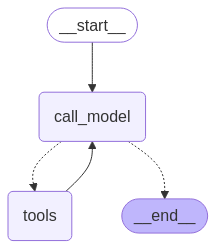

In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# 조건 분기 함수: 툴 호출이 필요한가?
def should_continue(state: State) -> Literal["tools", END]:  # 출력은 반드시 "tools" 혹은 END 여야 함.
    messages = state["messages"]
    last_message = messages[-1]  # 가장 최근 message
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")  # 루프 연결

# 컴파일
graph = builder.compile()

* 그래프 시각화

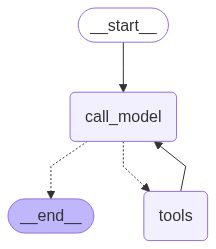

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="피타고라스의 정리를 설명해줘")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

피타고라스의 정리를 설명해줘
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_yXzliu9hZWZrnpe9jKwlPMSl)
 Call ID: call_yXzliu9hZWZrnpe9jKwlPMSl
  Args:
    query: Pythagorean theorem
================================= Tool Message =================================
Name: wikipedia

Page: Pythagorean theorem
Summary: In mathematics, the Pythagorean theorem or Pythagoras' theorem is a fundamental relation in Euclidean geometry between the three sides of a right triangle. It states that the area of the square whose side is the hypotenuse (the side opposite the right angle) is equal to the sum of the areas of the squares on the other two sides.
The theorem can be written as an equation relating the lengths of the sides a, b and the hypotenuse c, sometimes called the Pythagorean equation:

  
    
      
        
          a
          
            2
          
   

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="3의 제곱근은 얼마야?")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

3의 제곱근은 얼마야?
================================== Ai Message ==================================
Tool Calls:
  Calculator (call_pEvduRJp708uTkeWE4UgdWoz)
 Call ID: call_pEvduRJp708uTkeWE4UgdWoz
  Args:
    __arg1: sqrt(3)
================================= Tool Message =================================
Name: Calculator

Answer: 1.7320508075688772
================================== Ai Message ==================================

3의 제곱근은 약 1.732입니다.


## 4.실습

### (1) 실습1

* LLM을 하나 생성하시오 (ChatOpenAI)
* 다음 도구 3개를 load_tools()를 사용하여 불러오고, ToolNode로 묶으시오
    * llm-math, wikipedia, serpapi
* GPT에게 도구 목록을 알려주기 위해 .bind_tools(tools)를 사용하시오
* 이를 위해 필요한 준비작업을 수행하시오.
    * serpapi api key를 받아 등록
    * 필요한 라이브러리 설치

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt.tool_node import ToolNode
from langchain.agents import load_tools
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langchain_core.tools import tool

#### 1) Tool 준비하기

In [ ]:
!pip install google-search-results -q

  Preparing metadata (setup.py) ... done


In [ ]:
from langchain.agents import load_tools

llm = ChatOpenAI(model="gpt-4.1-mini")
tools = load_tools(["llm-math", "wikipedia", "serpapi"], llm=llm) # 일부 툴이 LLM을 내부적으로 쓸 때 필요한 설정


#### 2) ToolNode 생성

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
# 툴을 쓸 수 있는 LLM
llm_with_tools = llm.bind_tools(tools)  # GPT가 이 툴들을 사용하겠다고 판단할 수 있게 도와주는 설정

#### 3) 그래프 만들기

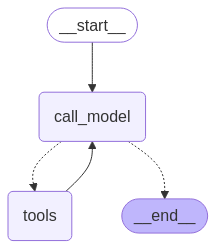

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# 조건 분기 함수: 툴 호출이 필요한가?
def should_continue(state: State) -> Literal["tools", END]:  # 출력은 반드시 "tools" 혹은 END 여야 함.
    messages = state["messages"]
    last_message = messages[-1]  # 가장 최근 message
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")  # 루프 연결

# 컴파일
graph = builder.compile()

* 그래프 시각화

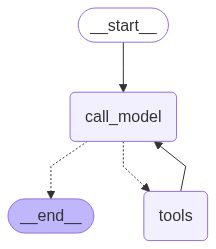

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="유로 2024 우승팀은?")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

유로 2024 우승팀은?
================================== Ai Message ==================================
Tool Calls:
  Search (call_IvH2y9OIDxm0dfOK75p2Xesq)
 Call ID: call_IvH2y9OIDxm0dfOK75p2Xesq
  Args:
    __arg1: Euro 2024 winner
================================= Tool Message =================================
Name: Search

Spain national football team
================================== Ai Message ==================================

현재 시점에서 유로 2024(UERO 2024) 축구 대회의 우승 팀은 아직 결정되지 않았습니다. 대회가 진행 중이거나 아직 시작되지 않았기 때문에 우승 팀 정보를 알 수 없습니다. 추가로 궁금한 점 있으면 알려주세요!


In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="deep seek가 주목받은 점은 무엇때문이야?")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

deep seek가 주목받은 점은 무엇때문이야?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_i1RbPEudxiWdac4DNBFLNFWl)
 Call ID: call_i1RbPEudxiWdac4DNBFLNFWl
  Args:
    query: Deep Seek
================================= Tool Message =================================
Name: wikipedia

Page: DeepSeek
Summary: Hangzhou DeepSeek Artificial Intelligence Basic Technology Research Co., Ltd., doing business as DeepSeek, is a Chinese artificial intelligence company that develops large language models (LLMs). Based in Hangzhou, Zhejiang, Deepseek is owned and funded by the Chinese hedge fund High-Flyer. DeepSeek was founded in July 2023 by Liang Wenfeng, the co-founder of High-Flyer, who also serves as the CEO for both of the companies. The company launched an eponymous chatbot alongside its DeepSeek-R1 model in January 2025.
Released under the MIT License, DeepSeek-R1 

### (3) 실습2

* 날씨 기반 의상 추천 에이전트
    * 지역 날씨 정보를 조회한 뒤
    * 해당 날씨에 맞는 옷차림을 추천하는
    * Tool 사용 기반 LangChain Agent
* 요구사항
    * get_weather 툴 정의 : 서울, 부산, 제주 중 입력받은 지역의 날씨 정보 반환
    * recommend_clothing 툴 정의 : 전달받은 날씨 정보(문자열)를 기반으로 옷차림 추천
    * 두 툴을 등록하여 에이전트 생성

* 사용자 질문 : "서울 날씨에 맞는 옷차림 추천해줘"
를 넣었을 때 → 날씨 툴 호출 → 옷 추천 툴 호출 → 답변

#### 1) Tool 준비하기

In [ ]:
llm = ChatOpenAI(model="gpt-4o")

In [ ]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """입력한 지역에 대한 고정된 날씨 정보를 반환합니다."""
    weather_db = {
        "서울": "흐림, 9도",
        "부산": "맑음, 18도",
        "제주": "비, 16도"
    }
    return weather_db.get(location, "날씨 정보를 찾을 수 없습니다.")

@tool
def recommend_clothing(weather: str) -> str:
    """날씨 정보를 기반으로 의상을 추천합니다."""
    if "흐림" in weather:
        return "긴팔과 가벼운 외투를 추천합니다."
    elif "맑음" in weather:
        return "반팔과 청바지를 추천합니다."
    elif "비" in weather:
        return "우산과 방수 재킷을 챙기세요."
    else:
        return "기본적인 외출 복장을 추천합니다."



#### 2) ToolNode 생성

In [ ]:
# 3. 툴과 LLM 연결
tools = [get_weather, recommend_clothing]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

#### 3) 그래프 만들기

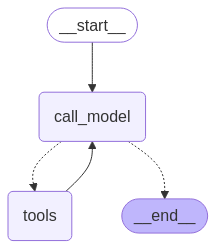

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 4. 모델 호출 노드
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": messages + [response]}

# 5. 조건 분기 함수: 툴 호출 여부 판단
def should_continue(state: State) -> Literal["tools", END]:
    messages = state["messages"]
    last = messages[-1]
    if last.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
# 6. 그래프 구성
builder = StateGraph(State)

builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")

graph = builder.compile()

* 그래프 시각화

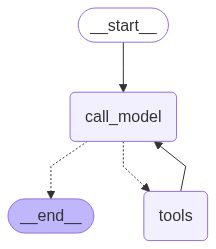

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
from langchain.schema import SystemMessage, HumanMessage

# 메시지 입력
inputs = {
    "messages": [
        SystemMessage(content="당신은 날씨에 따라 옷차림을 추천해주는 비서입니다."),
        HumanMessage(content="서울 날씨에 맞는 옷차림을 추천해줘")
    ]
}

result = graph.invoke(inputs)
for message in result["messages"]:
    message.pretty_print()

================================ System Message ================================

당신은 날씨에 따라 옷차림을 추천해주는 비서입니다.
================================ Human Message =================================

서울 날씨에 맞는 옷차림을 추천해줘
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_aumznRS4IZTYNteFoqeTVM1d)
 Call ID: call_aumznRS4IZTYNteFoqeTVM1d
  Args:
    location: 서울
================================= Tool Message =================================
Name: get_weather

흐림, 9도
================================== Ai Message ==================================
Tool Calls:
  recommend_clothing (call_SgWV7EIRL2KRh1KUwqZxKcmQ)
 Call ID: call_SgWV7EIRL2KRh1KUwqZxKcmQ
  Args:
    weather: 흐림, 9도
================================= Tool Message =================================
Name: recommend_clothing

긴팔과 가벼운 외투를 추천합니다.
================================== Ai Message ==================================

서울의 날씨는 현재 흐리고 기온은 9도로, 긴팔과 가벼운 외투를 착용하는 것이 좋겠습니다.


In [ ]:
inputs = {
    "messages": [
        SystemMessage(content="당신은 날씨에 따라 옷차림을 추천해주는 비서입니다."),
        HumanMessage(content="광주 날씨에 맞는 옷차림을 추천해줘")
    ]
}

result = graph.invoke(inputs)
for message in result["messages"]:
    message.pretty_print()

================================ System Message ================================

당신은 날씨에 따라 옷차림을 추천해주는 비서입니다.
================================ Human Message =================================

광주 날씨에 맞는 옷차림을 추천해줘
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_wtUmwumWy5ERVT0Svx64usxE)
 Call ID: call_wtUmwumWy5ERVT0Svx64usxE
  Args:
    location: 광주
================================= Tool Message =================================
Name: get_weather

날씨 정보를 찾을 수 없습니다.
================================== Ai Message ==================================

광주 날씨 정보를 얻을 수 없네요. 다른 지역이나 날씨를 아시고 싶으신 사항이 있으면 말씀해 주세요.
